# **All preprocessing of data before training ML and DL models**


# First I will import the libraries and do preprocessing so that the data will be used for training ML/DL models
- Each type of model requires different type of data i.e one type for ML and one type DL

In [ ]:
# ============================================
# 1. IMPORT LIBRARIES - for preprocessing before ML n DL
# ============================================
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier




In [ ]:
# ============================================
# 2. MOUNT GOOGLE DRIVE - as our data is stored in G-drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================
# 3. DEFINE FILE PATHS & LABELS - to mention the files located
# ============================================

data_path = "/content/drive/MyDrive/sajid_EEG_project/updated_csv_data_EEG"

In [ ]:
# Map each file to its label
file_label_map = {
    "Sub1EB.csv": "eye_blink",
    "Sub1EBM.csv": "eyebrow_movement",
    "Sub1EM.csv": "eye_movement",
    "Sub1HS.csv": "head_shake",
    "Sub1HT.csv": "head_nod",
    "Sub1LS.csv": "leg_shake",
    "Sub1Music.csv": "listening_music",
    "Sub1Relax.csv": "relaxed_closed",
    "Sub1Relaxopen.csv": "relaxed_open",
    "Sub1SUSD.csv": "sit_stand",
    "Sub1Talking.csv": "talking",
    "Sub1Walking.csv": "walking"
}

In [ ]:
# ============================================
# 4. LOAD & MERGE ALL FILES - we need to merge
# ============================================
dataframes = []

for file, label in file_label_map.items():
    df = pd.read_csv(os.path.join(data_path, file))
    df["label"] = label
    dataframes.append(df)

# Merge all - we will use concat to merging all
df_all = pd.concat(dataframes, ignore_index=True)

print("Merged shape:", df_all.shape)
print(df_all["label"].value_counts())

Merged shape: (67495, 24)
label
eye_movement        6028
eye_blink           5773
eyebrow_movement    5757
head_shake          5732
listening_music     5725
relaxed_open        5673
talking             5616
relaxed_closed      5593
head_nod            5591
walking             5400
sit_stand           5350
leg_shake           5257
Name: count, dtype: int64


To check for class imbalance

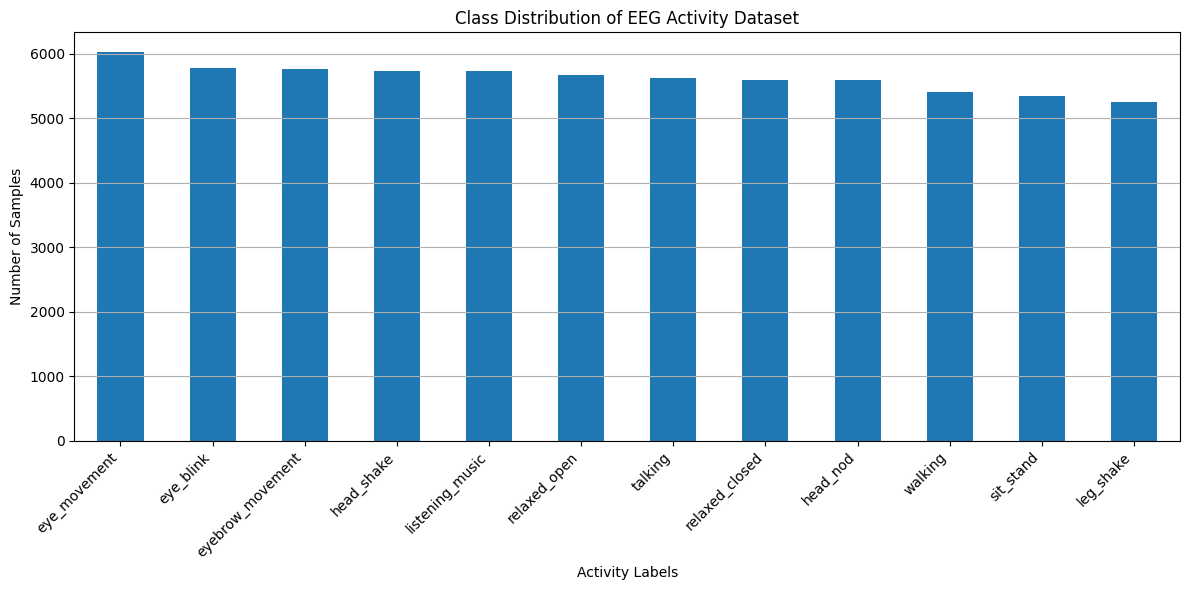

In [ ]:
import matplotlib.pyplot as plt

# Count labels
label_counts = df_all["label"].value_counts()

# Create bar plot
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')

# Labels and title
plt.xlabel("Activity Labels")
plt.ylabel("Number of Samples")
plt.title("Class Distribution of EEG Activity Dataset")

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')

# Show grid for better analysis
plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 6. SAVE MERGED DATASET AS CSV - one giant combined file
# ============================================

# Define output path (change folder name if needed)
output_path = "/content/drive/MyDrive/sajid_EEG_project/updated_csv_data_EEG/merged_EEG_dataset.csv"

# Save to CSV
df_all.to_csv(output_path, index=False)

print("Merged dataset saved successfully at:")
print(output_path)

Merged dataset saved successfully at:
/content/drive/MyDrive/sajid_EEG_project/updated_csv_data_EEG/merged_EEG_dataset.csv


In [ ]:
# ============================================
# 5. HANDLE MISSING VALUES- if we find some missing values
# ============================================
df_all.fillna(method='ffill', inplace=True)

# ============================================
# 6. NORMALIZATION - we need to normalization on all features
# ============================================
features = df_all.drop("label", axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

df_scaled = pd.DataFrame(scaled_features, columns=features.columns)
df_scaled["label"] = df_all["label"].values

/tmp/ipykernel_2679/322316990.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_all.fillna(method='ffill', inplace=True)


In [ ]:
print(df_scaled.head())

    EEG.AF3    EEG.F7    EEG.F3   EEG.FC5    EEG.T7    EEG.P7    EEG.O1  \
0  0.099911  0.165092  0.821901  0.735127  0.789616  0.265051  0.687204   
1  0.177555  0.182763  0.856461  0.796974  0.802226  0.288494  0.687204   
2  0.307499  0.204314  0.919640  0.854198  0.839457  0.298260  0.710913   
3  0.430432  0.207761  0.958520  0.868648  0.853269  0.302166  0.746933   
4  0.517242  0.205176  0.981740  0.881365  0.847263  0.276773  0.735535   

     EEG.O2    EEG.P8    EEG.T8  ...  MOT.GyroX  MOT.GyroY  MOT.GyroZ  \
0  0.648913  0.707779  0.805400  ...  -0.103766   0.685170  -0.102273   
1  0.671888  0.781621  0.773932  ...  -0.129434   0.723317  -0.088596   
2  0.707441  0.850570  0.732527  ...  -0.134567   0.751059  -0.095435   
3  0.716741  0.906618  0.686981  ...  -0.147401   0.782270  -0.088596   
4  0.703612  0.939533  0.649301  ...  -0.157668   0.796142  -0.061241   

   MOT.AccX  MOT.AccY  MOT.AccZ  MOT.MagX  MOT.MagY  MOT.MagZ      label  
0 -0.640305 -0.777290  1.433370  0.

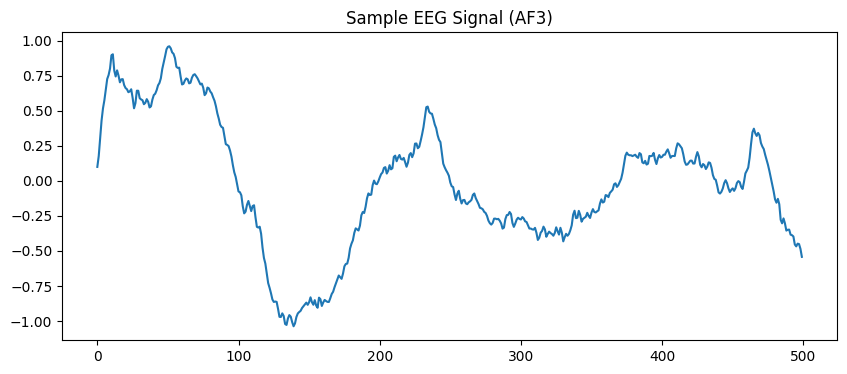

In [ ]:
# ============================================
# 7. EDA (quick visualization)
# ============================================
plt.figure(figsize=(10,4))
plt.plot(df_scaled["EEG.AF3"][:500])
plt.title("Sample EEG Signal (AF3)")
plt.show()

In [ ]:

# ============================================
# 8. WINDOWING FUNCTION - we need to create windows for experiments
# ============================================
def create_windows(data, labels, window_size, step_size):
    X = []
    y = []

    for i in range(0, len(data) - window_size, step_size):
        X.append(data[i:i+window_size])
        y.append(labels[i])

    return np.array(X), np.array(y)

# Parameters
window_size = 128   # i will try 128, 256 later
step_size = 64      # overlap

# Apply windowing
X, y = create_windows(
    df_scaled.drop("label", axis=1).values,
    df_scaled["label"].values,
    window_size,
    step_size
)

print("Windowed data shape:", X.shape)


Windowed data shape: (1053, 128, 23)


# **ML model on EEG+motion sensor data i.e including motion artifact sensor data i.e using all features**

In [ ]:
# ============================================
# 9. LABEL ENCODING - as y features - need to be converted into 12 categories 0-11
# ============================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
# ============================================
# 10. TRAIN-TEST SPLIT - before ML
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# ============================================
# 11. FLATTEN DATA FOR ML MODELS
# ============================================
# ML models need 2D input → flatten time dimension
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened shape:", X_train_flat.shape)


Flattened shape: (842, 2944)


In [ ]:
print("X_train_flat looks like", X_train_flat)
print("y_train_looks like",y_train)

X_train_flat looks like [[-8.07167741e-02 -8.42258097e-04 -3.46105896e-01 ...  6.05613238e-01
  -9.98681937e-02  1.53404588e-01]
 [ 3.36614224e-01 -4.39414600e-02 -3.25584955e-01 ...  5.04574968e-01
  -5.00448829e-01 -5.96475243e-01]
 [-5.93482011e-01  1.89658652e-01 -5.22144236e-01 ... -2.37501571e+00
  -8.60971401e-01  7.59076760e-01]
 ...
 [-7.96366110e-02  4.24983980e-01 -1.40908817e-01 ...  2.77238862e-01
  -3.13511199e-01  3.45681468e-01]
 [-2.55951643e-01 -2.97369243e-01 -1.57647637e-01 ...  1.06028545e+00
  -1.66631633e-01 -6.73385995e-01]
 [ 3.23674859e-01  1.31474071e-01  2.06848962e-01 ... -5.11355138e-02
  -4.20332702e-01  2.39929184e-01]]
y_train_looks like [ 3  4 10  0  1 10  7 11  6  0  9  7  6  0  7  8 11  4  5 10  1  8 10  7
  3 11  6  2  7  1  5 11  0  0  7  8  4  4  2  3 10  9  4 11  9  0  0  0
  4  1  9  4  5  4  0  2  8  7  9  1  4  5  7 11  1  8  8  9  5  3 11  3
  4  8  4  6  5  8  1  9  9  3  1  2  3  4  5 10  2  9  5  1  2  2  5  1
  6 10  0  5  3 10 10  4 11  

In [ ]:
# ============================================
# 12. TRAIN ML MODELS
# ============================================
#  LightGBM
lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=-1,
    learning_rate=0.1,
    random_state=42
)
lgbm.fit(X_train_flat, y_train)



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.073669 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 679024
[LightGBM] [Info] Number of data points in the train set: 842, number of used features: 2944
[LightGBM] [Info] Start training from score -2.445321
[LightGBM] [Info] Start training from score -2.418292
[LightGBM] [Info] Start training from score -2.459114
[LightGBM] [Info] Start training from score -2.487285
[LightGBM] [Info] Start training from score -2.473100
[LightGBM] [Info] Start training from score -2.546125
[LightGBM] [Info] Start training from score -2.473100
[LightGBM] [Info] Start training from score -2.473100
[LightGBM] [Info] Start training from score -2.487285
[LightGBM] [Info] Start training from score -2.531087
[LightGBM] [Info] Start training from score -2.487285
[LightGBM] [Info] Start training from score -2.546125
[LightGBM] [Warning] No further splits with positive gain, be

LGBMClassifier(n_estimators=200, random_state=42)


===== Random Forest Results =====
Accuracy: 0.8815165876777251

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       1.00      0.89      0.94        19
           2       0.84      0.89      0.86        18
           3       0.84      0.89      0.86        18
           4       0.70      0.89      0.78        18
           5       0.83      0.94      0.88        16
           6       1.00      0.83      0.91        18
           7       1.00      0.94      0.97        17
           8       0.85      0.94      0.89        18
           9       0.81      0.76      0.79        17
          10       0.94      0.94      0.94        18
          11       0.87      0.81      0.84        16

    accuracy                           0.88       211
   macro avg       0.89      0.88      0.88       211
weighted avg       0.89      0.88      0.88       211



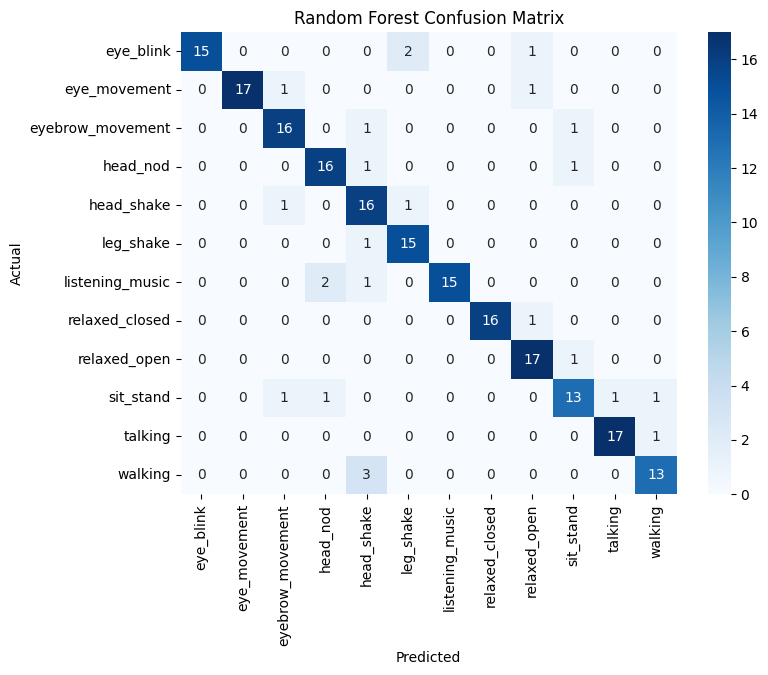


===== SVC Results =====
Accuracy: 0.7914691943127962

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.28      0.38        18
           1       0.76      0.84      0.80        19
           2       0.71      0.67      0.69        18
           3       0.73      0.61      0.67        18
           4       1.00      0.72      0.84        18
           5       1.00      0.94      0.97        16
           6       0.94      0.89      0.91        18
           7       0.83      0.88      0.86        17
           8       0.57      0.94      0.71        18
           9       0.83      0.88      0.86        17
          10       1.00      0.89      0.94        18
          11       0.70      1.00      0.82        16

    accuracy                           0.79       211
   macro avg       0.81      0.80      0.79       211
weighted avg       0.81      0.79      0.78       211



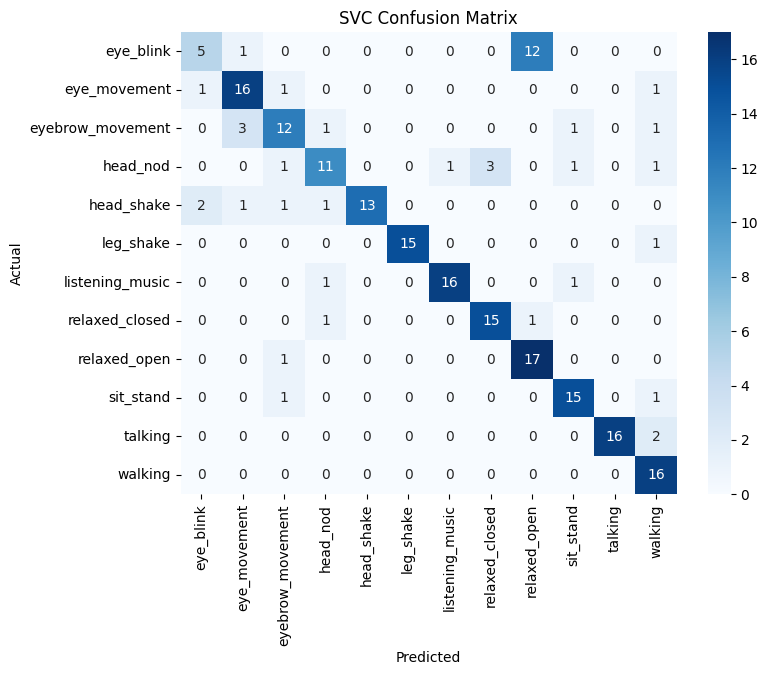

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== LightGBM (EEG Only) Results =====
Accuracy: 0.9052132701421801

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       1.00      0.89      0.94        19
           2       0.86      1.00      0.92        18
           3       0.80      0.89      0.84        18
           4       0.93      0.78      0.85        18
           5       0.83      0.94      0.88        16
           6       1.00      0.94      0.97        18
           7       1.00      0.94      0.97        17
           8       0.86      1.00      0.92        18
           9       0.82      0.82      0.82        17
          10       0.94      0.94      0.94        18
          11       0.88      0.88      0.88        16

    accuracy                           0.91       211
   macro avg       0.91      0.91      0.90       211
weighted avg       0.91      0.91      0.91       211



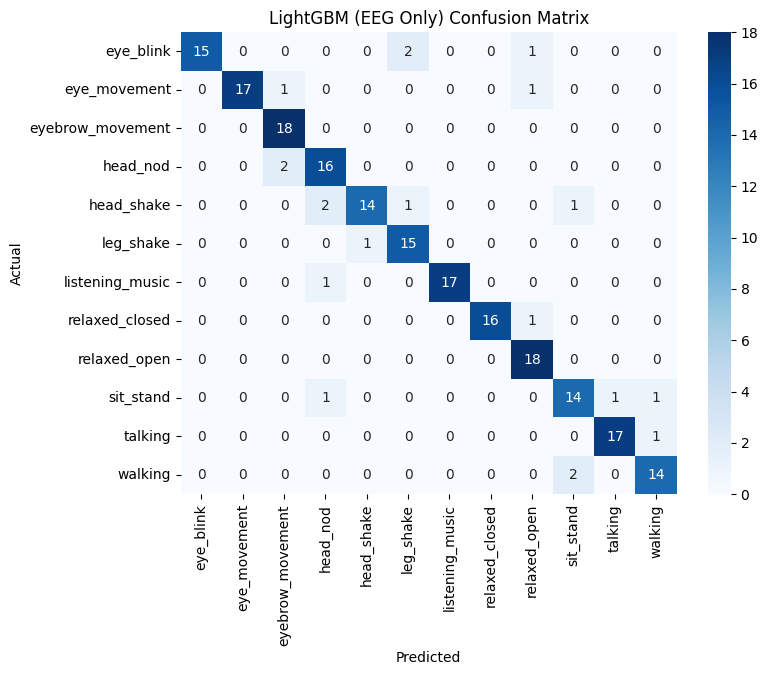

In [ ]:


# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_flat, y_train)

# Support Vector Classifier (SVC)
from sklearn.svm import SVC
svc = SVC(kernel='rbf', C=1.0, random_state=42)
svc.fit(X_train_flat, y_train)


# ============================================
# 13. EVALUATION FUNCTION - we need to evaluate on different metrics
# ============================================
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    print(f"\n===== {name} Results =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ============================================
# 14. EVALUATE MODELS - for all 3 models
# ============================================
evaluate_model(rf, X_test_flat, y_test, "Random Forest")
evaluate_model(svc, X_test_flat, y_test, "SVC")
evaluate_model(lgbm, X_test_flat, y_test, "LightGBM ")

Table: Machine Learning Model Performance (EEG Only)

Model======	Accuracy	Precision	Recall 	F1-Score

Random Forest=	0.88	0.89	0.88	0.88

SVC====	0.79	0.81	0.79	0.78

LightGBM===	0.91	0.91	0.91	0.91

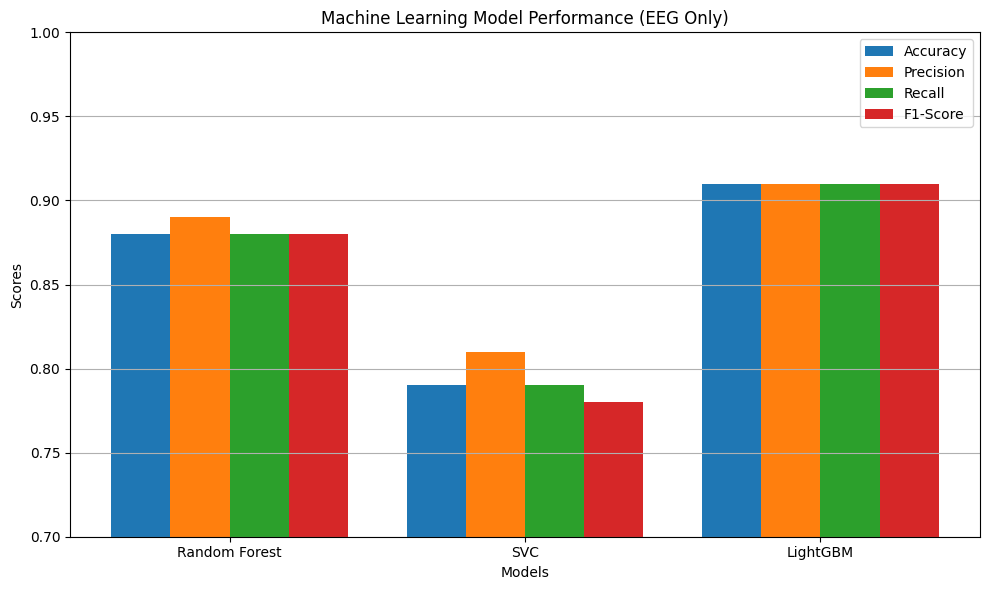

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Random Forest', 'SVC', 'LightGBM']

# Metrics
accuracy = [0.88, 0.79, 0.91]
precision = [0.89, 0.81, 0.91]
recall = [0.88, 0.79, 0.91]
f1_score = [0.88, 0.78, 0.91]

# X-axis positions
x = np.arange(len(models))
width = 0.2  # width of bars

# Plot
plt.figure(figsize=(10, 6))

plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1_score, width, label='F1-Score')

# Labels and title
plt.xlabel("Models")
plt.ylabel("Scores")
plt.title("Machine Learning Model Performance (EEG Only)")
plt.xticks(x, models)
plt.ylim(0.7, 1.0)

# Legend
plt.legend()

plt.grid(axis='y')
plt.tight_layout()
plt.show()

as we can see from above:

The bar chart compares the performance of classical machine learning models on EEG-only data. LightGBM demonstrates the highest performance across all evaluation metrics, followed by Random Forest, while SVC shows comparatively lower results. The consistency across accuracy, precision, recall, and F1-score indicates stable model behaviour, with LightGBM emerging as the most effective model for this task.

# **Experiments run on diff Window sizes- ML algos & comparison table**

# Here we will change the different window sizes to basically check or experiment whether it affects the accuracy of models

In [ ]:
# ============================================
# IMPORTS
# ============================================
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# FILE PATH
# ============================================
data_path = "/content/drive/MyDrive/sajid_EEG_project/updated_csv_data_EEG/"  # CHANGE THIS

# ============================================
# FILE → LABEL MAP
# ============================================
file_label_map = {
    "Sub1SUSD.csv": "sit_stand",
    "Sub1Talking.csv": "talking",
    "Sub1Walking.csv": "walking",
    "Sub1EB.csv": "eye_blink",
    "Sub1EBM.csv": "eyebrow",
    "Sub1EM.csv": "eye_movement",
    "Sub1HS.csv": "head_shake",
    "Sub1HT.csv": "head_nod",
    "Sub1LS.csv": "leg_shake",
    "Sub1Music.csv": "music",
    "Sub1Relax.csv": "relaxed_closed",
    "Sub1Relaxopen.csv": "relaxed_open"
}


# ============================================
# WINDOW FUNCTION
# ============================================
def create_windows(data, window_size, overlap):
    step = int(window_size * (1 - overlap))
    windows = []
    for i in range(0, len(data) - window_size, step):
        windows.append(data[i:i+window_size])
    return np.array(windows)

# ============================================
# BUILD DATASET (EEG + MOTION)
# ============================================
def build_dataset(window_size=128, overlap=0.5):

    X_all = []
    y_all = []

    # find common columns
    common_cols = None
    for file in file_label_map:
        df = pd.read_csv(os.path.join(data_path, file))
        cols = set(df.columns)
        if common_cols is None:
            common_cols = cols
        else:
            common_cols = common_cols.intersection(cols)

    common_cols = sorted(list(common_cols))

    # build dataset
    for file, label in file_label_map.items():
        df = pd.read_csv(os.path.join(data_path, file))
        df = df[common_cols]

        df.fillna(method='ffill', inplace=True)

        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(df)

        windows = create_windows(data_scaled, window_size, overlap)

        labels = [label] * len(windows)

        X_all.append(windows)
        y_all.extend(labels)

    X_all = np.vstack(X_all)
    y_all = np.array(y_all)

    return X_all, y_all

In [ ]:


# ============================================
# EVALUATION FUNCTION
# ============================================
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

# ============================================
# MODELS
# ============================================
rf = RandomForestClassifier(n_estimators=150, random_state=42)

svm = SVC(kernel='rbf', C=5, gamma='scale')


lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=-1,
    learning_rate=0.1,
    random_state=42
)


In [ ]:

# ============================================
# WINDOW EXPERIMENT
# ============================================
window_sizes = [64, 128, 256]
overlap = 0.5

le = LabelEncoder()

for w in window_sizes:
    print(f"\n\n========= WINDOW SIZE: {w} =========")

    X, y = build_dataset(window_size=w, overlap=overlap)

    y = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # flatten for ML
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    # train
    rf.fit(X_train_flat, y_train)
    svm.fit(X_train_flat, y_train)
    lgbm.fit(X_train_flat, y_train)

    # evaluate
    evaluate_model(rf, X_test_flat, y_test, f"RF (W={w})")
    evaluate_model(svm, X_test_flat, y_test, f"SVM (W={w})")
    evaluate_model(lgbm, X_test_flat, y_test, f"LightGBM (W={w})")



========= WINDOW SIZE: 64 =========


/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Us

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.065866 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 375360
[LightGBM] [Info] Number of data points in the train set: 1672, number of used features: 1472
[LightGBM] [Info] Start training from score -2.458931
[LightGBM] [Info] Start training from score -2.411140
[LightGBM] [Info] Start training from score -2.465949
[LightGBM] [Info] Start training from score -2.494522
[LightGBM] [Info] Start training from score -2.465949
[LightGBM] [Info] Start training from score -2.554241
[LightGBM] [Info] Start training from score -2.465949
[LightGBM] [Info] Start training from score -2.494522
[LightGBM] [Info] Start training from score -2.473016
[LightGBM] [Info] Start training from score -2.531427
[LightGBM] [Info] Start training from score -2.487302
[LightGBM] [Info] Start training from score -2.523936
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.127508 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 750282
[LightGBM] [Info] Number of data points in the train set: 829, number of used features: 2944
[LightGBM] [Info] Start training from score -2.457540
[LightGBM] [Info] Start training from score -2.416155
[LightGBM] [Info] Start training from score -2.471725
[LightGBM] [Info] Start training from score -2.486114
[LightGBM] [Info] Start training from score -2.471725
[LightGBM] [Info] Start training from score -2.545833
[LightGBM] [Info] Start training from score -2.471725
[LightGBM] [Info] Start training from score -2.486114
[LightGBM] [Info] Start training from score -2.471725
[LightGBM] [Info] Start training from score -2.530565
[LightGBM] [Info] Start training from score -2.486114
[LightGBM] [Info] Start training from score -2.530565
[LightGBM] [Warning] No further splits with positive gain, be

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2070316553.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.086069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 783385
[LightGBM] [Info] Number of data points in the train set: 407, number of used features: 5888
[LightGBM] [Info] Start training from score -2.453465
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.543077
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.543077
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.512306
[LightGBM] [Warning] No further splits with positive gain, be

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Performance Comparison Across Window Sizes

Window Size	Model	Accuracy	Precision (Weighted)	Recall (Weighted)	F1-Score (Weighted)

64
  Random Forest	0.845	0.85	0.84	0.84

	SVM	0.814	0.83	0.81	0.82

	LightGBM	0.907	0.91	0.91	0.91
  

128
  Random Forest	0.803	0.81	0.80	0.80

  SVM	0.635	0.64	0.63	0.63

  LightGBM	0.798	0.81	0.80	0.80

256
  Random Forest	0.657	0.67	0.66	0.66

	SVM	0.284	0.33	0.28	0.29

	LightGBM	0.569	0.58	0.57	0.57

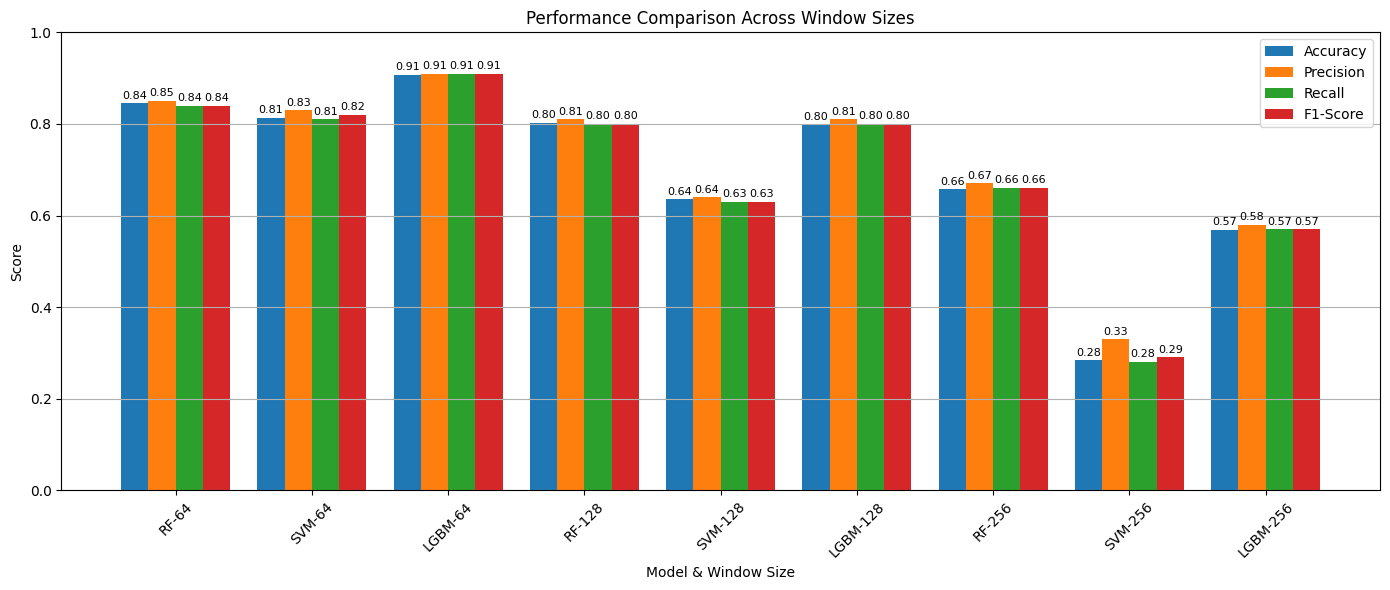

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Labels
labels = [
    'RF-64', 'SVM-64', 'LGBM-64',
    'RF-128', 'SVM-128', 'LGBM-128',
    'RF-256', 'SVM-256', 'LGBM-256'
]

# Metrics data
accuracy = [0.845, 0.814, 0.907, 0.803, 0.635, 0.798, 0.657, 0.284, 0.569]
precision = [0.85, 0.83, 0.91, 0.81, 0.64, 0.81, 0.67, 0.33, 0.58]
recall = [0.84, 0.81, 0.91, 0.80, 0.63, 0.80, 0.66, 0.28, 0.57]
f1_score = [0.84, 0.82, 0.91, 0.80, 0.63, 0.80, 0.66, 0.29, 0.57]

# X positions
x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(14, 6))

# Bars
bars1 = plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
bars2 = plt.bar(x - 0.5*width, precision, width, label='Precision')
bars3 = plt.bar(x + 0.5*width, recall, width, label='Recall')
bars4 = plt.bar(x + 1.5*width, f1_score, width, label='F1-Score')

# Add values on top
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                 f'{height:.2f}', ha='center', fontsize=8)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

# Labels and title
plt.xlabel("Model & Window Size")
plt.ylabel("Score")
plt.title("Performance Comparison Across Window Sizes")
plt.xticks(x, labels, rotation=45)
plt.ylim(0, 1.0)

plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()

The results demonstrate on EEG + motion sensor data - a clear impact of window size on model performance, with smaller window sizes yielding significantly better outcomes. Specifically, a window size of 64 achieves the highest accuracy and consistency across all models, particularly with LightGBM performing best overall. As the window size increases to 128 and 256, there is a noticeable decline in performance across all metrics, with the degradation being most severe for SVM. This suggests that smaller windows are more effective in capturing fine-grained temporal patterns in EEG signals, while larger windows may introduce noise or dilute important signal variations. Overall, the findings highlight that optimal window selection is critical for achieving robust and accurate EEG-based classification.

# **for RQ2 n comparison-ML model on only EEG data excluding motion sensor data - for RQ2 - ignoring motion sensor data**

# Here we basically do similar process like above except we will remove features such as motion sensors to check whether it will affect accuracy and in what ways

In [ ]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier


# ============================================
# 2. MOUNT GOOGLE DRIVE
# ============================================
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================
# 3. LOAD MERGED DATASET
# ============================================
data_path = "/content/drive/MyDrive/sajid_EEG_project/updated_csv_data_EEG/merged_EEG_dataset.csv"
df_all = pd.read_csv(data_path)

print("Original shape:", df_all.shape)

Original shape: (67495, 24)


In [ ]:


# ============================================
# 4. REMOVE MOTION SENSOR COLUMNS
# ============================================



motion_keywords = [
    "MOT.GyroX", "MOT.GyroY", "MOT.GyroZ",
    "MOT.AccX",  "MOT.AccY",  "MOT.AccZ",
    "MOT.MagX",  "MOT.MagY",  "MOT.MagZ"
]

eeg_columns = [col for col in df_all.columns
               if not any(keyword in col for keyword in motion_keywords)]

# Keep EEG + label
df_eeg_only = df_all[eeg_columns]

print("EEG-only shape:", df_eeg_only.shape)

EEG-only shape: (67495, 15)


In [ ]:


# ============================================
# 5. HANDLE MISSING VALUES
# ============================================
df_eeg_only.fillna(method='ffill', inplace=True)

# ============================================
# 6. NORMALIZATION
# ============================================
features = df_eeg_only.drop("label", axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

df_scaled = pd.DataFrame(scaled_features, columns=features.columns)
df_scaled["label"] = df_eeg_only["label"].values

# ============================================
# 7. WINDOWING FUNCTION
# ============================================
def create_windows(data, labels, window_size, step_size):
    X = []
    y = []

    for i in range(0, len(data) - window_size, step_size):
        X.append(data[i:i+window_size])
        y.append(labels[i])

    return np.array(X), np.array(y)

window_size = 128
step_size = 64

X, y = create_windows(
    df_scaled.drop("label", axis=1).values,
    df_scaled["label"].values,
    window_size,
    step_size
)

print("Windowed shape:", X.shape)

Windowed shape: (1053, 128, 14)


/tmp/ipykernel_2679/1409179739.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_eeg_only.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/1409179739.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eeg_only.fillna(method='ffill', inplace=True)


In [ ]:


# ============================================
# 8. LABEL ENCODING
# ============================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ============================================
# 9. TRAIN-TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# ============================================
# 10. FLATTEN FOR ML MODELS
# ============================================
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened shape:", X_train_flat.shape)

Flattened shape: (842, 1792)


In [ ]:


# ============================================
# 11. TRAIN MODELS
# ============================================

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_flat, y_train)

# SVM
svm = SVC(kernel='rbf')
svm.fit(X_train_flat, y_train)

SVC()

In [ ]:
# LightGBM
lgbm1 = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    min_child_samples=10,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=0.0,
    n_jobs=-1,
    random_state=42
)
lgbm1.fit(X_train_flat, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.066543 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 456960
[LightGBM] [Info] Number of data points in the train set: 842, number of used features: 1792
[LightGBM] [Info] Start training from score -2.445321
[LightGBM] [Info] Start training from score -2.418292
[LightGBM] [Info] Start training from score -2.459114
[LightGBM] [Info] Start training from score -2.487285
[LightGBM] [Info] Start training from score -2.473100
[LightGBM] [Info] Start training from score -2.546125
[LightGBM] [Info] Start training from score -2.473100
[LightGBM] [Info] Start training from score -2.473100
[LightGBM] [Info] Start training from score -2.487285
[LightGBM] [Info] Start training from score -2.531087
[LightGBM] [Info] Start training from score -2.487285
[LightGBM] [Info] Start training from score -2.546125
[LightGBM] [Warning] No further splits with positive gain, be

LGBMClassifier(colsample_bytree=0.9, learning_rate=0.05, min_child_samples=10,
               n_estimators=400, n_jobs=-1, num_leaves=64, random_state=42,
               subsample=0.9)


===== RF (EEG Only) Results =====
Accuracy: 0.4218009478672986

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.22      0.24        18
           1       0.26      0.26      0.26        19
           2       0.39      0.61      0.48        18
           3       0.36      0.44      0.40        18
           4       0.39      0.39      0.39        18
           5       0.31      0.25      0.28        16
           6       1.00      0.89      0.94        18
           7       0.17      0.12      0.14        17
           8       0.34      0.56      0.43        18
           9       0.78      0.82      0.80        17
          10       0.44      0.39      0.41        18
          11       0.20      0.06      0.10        16

    accuracy                           0.42       211
   macro avg       0.41      0.42      0.41       211
weighted avg       0.41      0.42      0.41       211



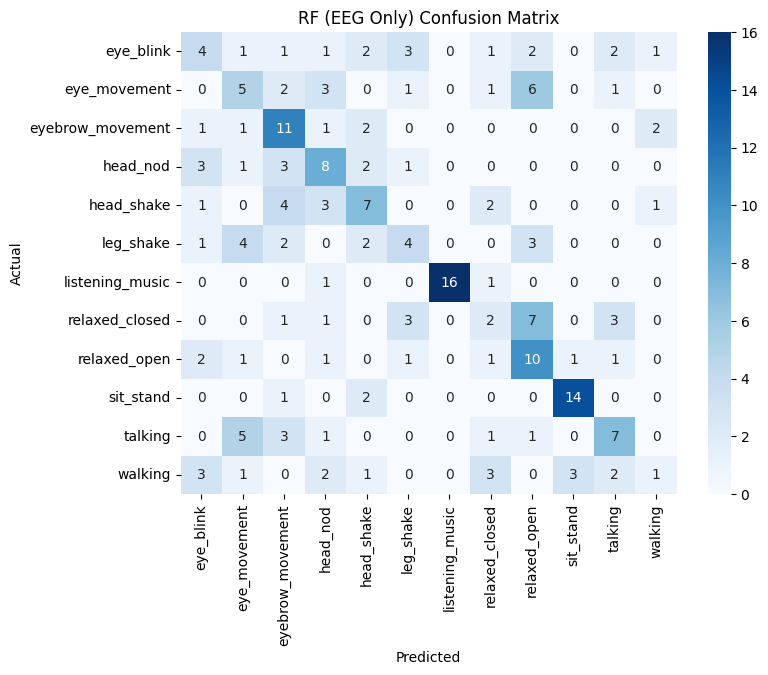


===== SVM (EEG Only) Results =====
Accuracy: 0.3080568720379147

Classification Report:
              precision    recall  f1-score   support

           0       0.09      0.06      0.07        18
           1       0.05      0.05      0.05        19
           2       0.23      0.17      0.19        18
           3       0.54      0.39      0.45        18
           4       0.42      0.28      0.33        18
           5       0.14      0.06      0.09        16
           6       0.94      0.89      0.91        18
           7       0.00      0.00      0.00        17
           8       0.19      0.39      0.25        18
           9       0.92      0.71      0.80        17
          10       0.15      0.44      0.23        18
          11       0.40      0.25      0.31        16

    accuracy                           0.31       211
   macro avg       0.34      0.31      0.31       211
weighted avg       0.34      0.31      0.31       211



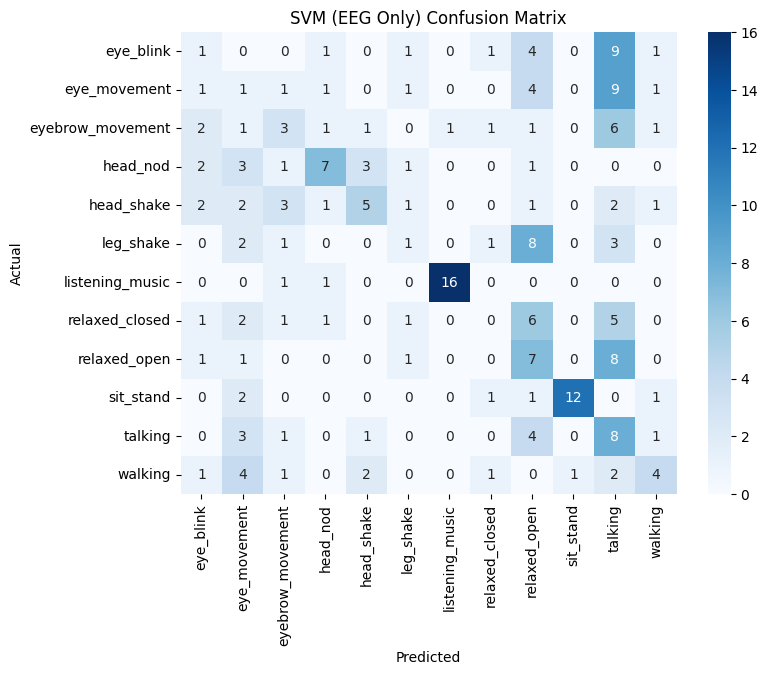

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== LightGBM (EEG Only) Results =====
Accuracy: 0.4075829383886256

Classification Report:
              precision    recall  f1-score   support

           0       0.15      0.11      0.13        18
           1       0.26      0.26      0.26        19
           2       0.43      0.56      0.49        18
           3       0.30      0.33      0.32        18
           4       0.50      0.44      0.47        18
           5       0.21      0.31      0.25        16
           6       0.94      0.94      0.94        18
           7       0.27      0.18      0.21        17
           8       0.32      0.39      0.35        18
           9       0.80      0.71      0.75        17
          10       0.46      0.33      0.39        18
          11       0.29      0.31      0.30        16

    accuracy                           0.41       211
   macro avg       0.41      0.41      0.41       211
weighted avg       0.41      0.41      0.41       211



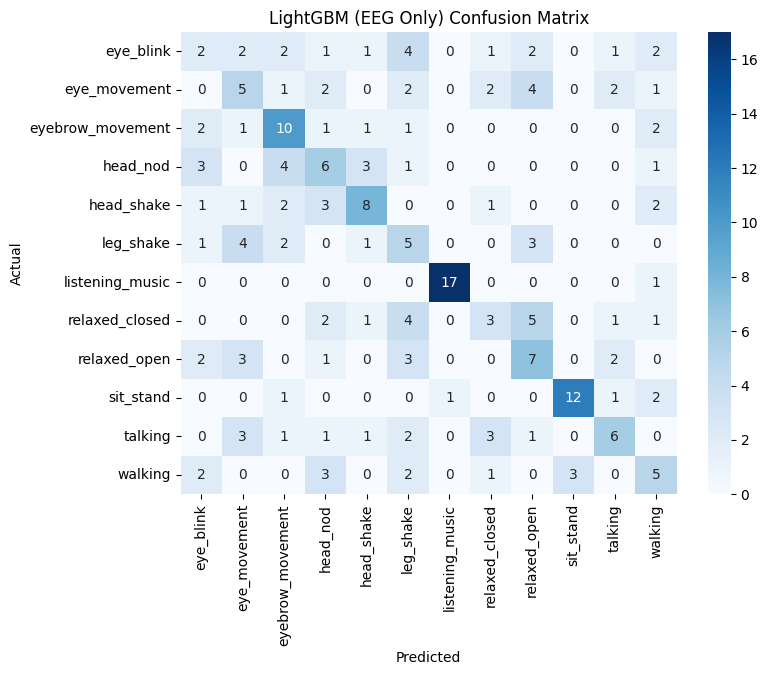

In [ ]:
# ============================================
# 11. TRAIN MODELS
# ============================================

# Random Forest
#rf = RandomForestClassifier(n_estimators=100, random_state=42)
#rf.fit(X_train_flat, y_train)

# SVM
#svm = SVC(kernel='rbf')
#svm.fit(X_train_flat, y_train)

# ============================================
# 12. EVALUATION FUNCTION
# ============================================
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    print(f"\n===== {name} Results =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ============================================
# 13. EVALUATE
# ============================================
evaluate_model(rf, X_test_flat, y_test, "RF (EEG Only)")
evaluate_model(svm, X_test_flat, y_test, "SVM (EEG Only)")
evaluate_model(lgbm1, X_test_flat, y_test, "LightGBM (EEG Only)")

Machine Learning Performance (EEG Only)

Model	Accuracy	Precision (Weighted Avg)	Recall (Weighted Avg)	F1-Score (Weighted Avg)

Random Forest	0.422	0.41	0.42	0.41

SVM	0.308	0.34	0.31	0.31

LightGBM	0.408	0.41	0.41	0.41

# **Diff-Window-sizes-For only EEG data excluding motion sensor data - experiments on different window sizes**

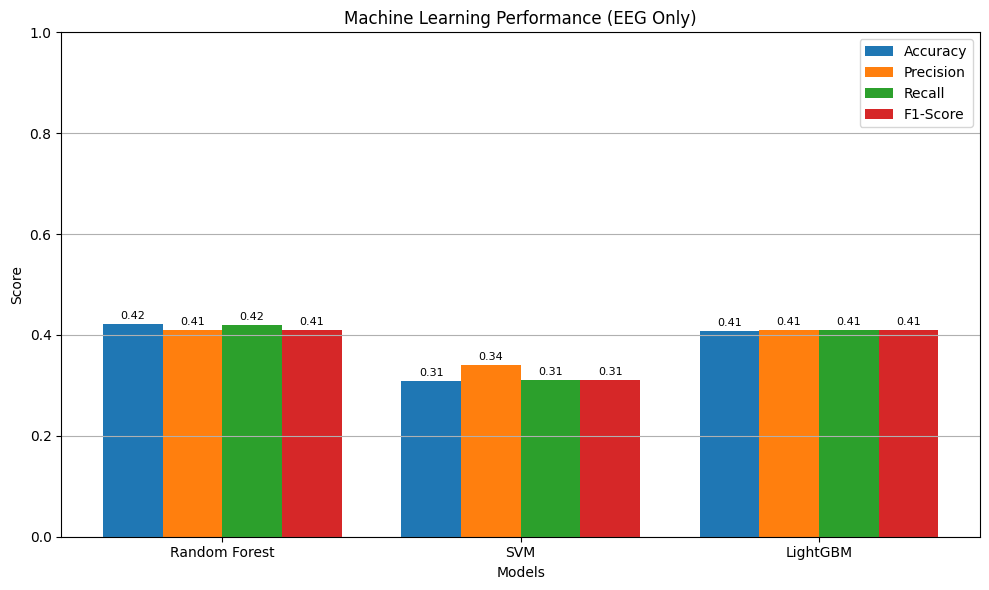

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Random Forest', 'SVM', 'LightGBM']

accuracy = [0.422, 0.308, 0.408]
precision = [0.41, 0.34, 0.41]
recall = [0.42, 0.31, 0.41]
f1 = [0.41, 0.31, 0.41]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
bars2 = plt.bar(x - 0.5*width, precision, width, label='Precision')
bars3 = plt.bar(x + 0.5*width, recall, width, label='Recall')
bars4 = plt.bar(x + 1.5*width, f1, width, label='F1-Score')

# Add values
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', fontsize=8)

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Machine Learning Performance (EEG Only)")
plt.xticks(x, models)
plt.ylim(0, 1)

plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The results indicate relatively low performance across all machine learning models when using EEG-only data, suggesting limitations in feature representation. Random Forest and LightGBM exhibit similar performance, slightly outperforming SVM across all evaluation metrics. However, the overall accuracy and F1-scores remain modest, highlighting the challenges of classifying complex EEG signals without additional contextual or multimodal inputs. These findings suggest that EEG-only features may not be sufficiently discriminative for achieving high classification accuracy.

# Here we will conduct experiments on different window size only on EEG data i.e excluding motion sensor features etc - however the process will remain same like above

In [ ]:
# ============================================
# IMPORTS
# ============================================
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier

# ============================================
# FILE PATH
# ============================================
data_path = "/content/drive/MyDrive/sajid_EEG_project/updated_csv_data_EEG/"  # CHANGE THIS

# ============================================
# FILE → LABEL MAP
# ============================================
file_label_map = {
    "Sub1SUSD.csv": "sit_stand",
    "Sub1Talking.csv": "talking",
    "Sub1Walking.csv": "walking",
    "Sub1EB.csv": "eye_blink",
    "Sub1EBM.csv": "eyebrow",
    "Sub1EM.csv": "eye_movement",
    "Sub1HS.csv": "head_shake",
    "Sub1HT.csv": "head_nod",
    "Sub1LS.csv": "leg_shake",
    "Sub1Music.csv": "music",
    "Sub1Relax.csv": "relaxed_closed",
    "Sub1Relaxopen.csv": "relaxed_open"
}


In [ ]:

# ============================================
# WINDOW FUNCTION
# ============================================
def create_windows(data, window_size, overlap):
    step = int(window_size * (1 - overlap))
    windows = []
    for i in range(0, len(data) - window_size, step):
        windows.append(data[i:i+window_size])
    return np.array(windows)

# ============================================
# BUILD DATASET (EEG ONLY)
# ============================================
def build_dataset_eeg_only(window_size=128, overlap=0.5):

    X_all = []
    y_all = []

    common_cols = None

    # Identify EEG-only columns
    for file in file_label_map:
        df = pd.read_csv(os.path.join(data_path, file))

        # Remove motion columns
        motion_keywords = [ "MOT.GyroX", "MOT.GyroY", "MOT.GyroZ",
              "MOT.AccX",  "MOT.AccY",  "MOT.AccZ",
              "MOT.MagX",  "MOT.MagY",  "MOT.MagZ"]

        df = df[[col for col in df.columns if not any(k in col for k in motion_keywords)]]

        cols = set(df.columns)

        if common_cols is None:
            common_cols = cols
        else:
            common_cols = common_cols.intersection(cols)

    common_cols = sorted(list(common_cols))



    # Build dataset
    for file, label in file_label_map.items():
        df = pd.read_csv(os.path.join(data_path, file))

        # Remove motion columns
        motion_keywords = [
              "MOT.GyroX", "MOT.GyroY", "MOT.GyroZ",
              "MOT.AccX",  "MOT.AccY",  "MOT.AccZ",
              "MOT.MagX",  "MOT.MagY",  "MOT.MagZ"
            ]
        df = df[[col for col in df.columns if not any(k in col for k in motion_keywords)]]

        df = df[common_cols]

        df.fillna(method='ffill', inplace=True)

        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(df)

        windows = create_windows(data_scaled, window_size, overlap)

        labels = [label] * len(windows)

        X_all.append(windows)
        y_all.extend(labels)

    X_all = np.vstack(X_all)
    y_all = np.array(y_all)

    return X_all, y_all

In [ ]:


# ============================================
# EVALUATION FUNCTION
# ============================================
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

# ============================================
# MODELS
# ============================================
rf = RandomForestClassifier(n_estimators=150, random_state=42)

svm = SVC(kernel='rbf', C=5, gamma='scale')

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)

# ============================================
# WINDOW EXPERIMENT (EEG ONLY)
# ============================================
window_sizes = [64, 128, 256]
overlap = 0.5

le = LabelEncoder()

for w in window_sizes:
    print(f"\n\n========= WINDOW SIZE: {w} =========")

    X, y = build_dataset_eeg_only(window_size=w, overlap=overlap)

    y = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Flatten for ML
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    # Train
    rf.fit(X_train_flat, y_train)
    svm.fit(X_train_flat, y_train)
    lgbm.fit(X_train_flat, y_train)

    # Evaluate
    evaluate_model(rf, X_test_flat, y_test, f"RF EEG Only (W={w})")
    evaluate_model(svm, X_test_flat, y_test, f"SVM EEG Only (W={w})")
    evaluate_model(lgbm, X_test_flat, y_test, f"LightGBM EEG Only (W={w})")



========= WINDOW SIZE: 64 =========


/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Us

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023870 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 228480
[LightGBM] [Info] Number of data points in the train set: 1672, number of used features: 896
[LightGBM] [Info] Start training from score -2.458931
[LightGBM] [Info] Start training from score -2.411140
[LightGBM] [Info] Start training from score -2.465949
[LightGBM] [Info] Start training from score -2.494522
[LightGBM] [Info] Start training from score -2.465949
[LightGBM] [Info] Start training from score -2.554241
[LightGBM] [Info] Start training from score -2.465949
[LightGBM] [Info] Start training from score -2.494522
[LightGBM] [Info] Start training from score -2.473016
[LightGBM] [Info] Start training from score -2.531427
[LightGBM] [Info] Start training from score -2.487302
[LightGBM] [Info] Start training from score -2.523936
[LightGBM] [Warning] No further splits with positive gain, be

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== LightGBM EEG Only (W=64) =====
Accuracy: 0.5966587112171837
              precision    recall  f1-score   support

           0       0.58      0.72      0.64        36
           1       0.47      0.46      0.47        37
           2       0.43      0.53      0.47        36
           3       0.63      0.54      0.58        35
           4       0.56      0.42      0.48        36
           5       0.71      0.73      0.72        33
           6       0.94      0.94      0.94        35
           7       0.66      0.54      0.59        35
           8       0.67      0.74      0.70        35
           9       0.73      0.73      0.73        33
          10       0.39      0.40      0.39        35
          11       0.45      0.42      0.44        33

    accuracy                           0.60       419
   macro avg       0.60      0.60      0.60       419
weighted avg       0.60      0.60      0.60       419



========= WINDOW SIZE: 128 =========


/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Us

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041842 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 456960
[LightGBM] [Info] Number of data points in the train set: 829, number of used features: 1792
[LightGBM] [Info] Start training from score -2.457540
[LightGBM] [Info] Start training from score -2.416155
[LightGBM] [Info] Start training from score -2.471725
[LightGBM] [Info] Start training from score -2.486114
[LightGBM] [Info] Start training from score -2.471725
[LightGBM] [Info] Start training from score -2.545833
[LightGBM] [Info] Start training from score -2.471725
[LightGBM] [Info] Start training from score -2.486114
[LightGBM] [Info] Start training from score -2.471725
[LightGBM] [Info] Start training from score -2.530565
[LightGBM] [Info] Start training from score -2.486114
[LightGBM] [Info] Start training from score -2.530565
[LightGBM] [Warning] No further splits with positive gain, be

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2770351568.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.044597 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 487433
[LightGBM] [Info] Number of data points in the train set: 407, number of used features: 3584
[LightGBM] [Info] Start training from score -2.453465
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.543077
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.543077
[LightGBM] [Info] Start training from score -2.482453
[LightGBM] [Info] Start training from score -2.512306
[LightGBM] [Warning] No further splits with positive gain, be

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


EEG-Only Performance Across Window Sizes

Window Size	Model	Accuracy	Precision (Weighted)	Recall (Weighted)	F1-Score (Weighted)

64	Random Forest	0.597	0.61	0.60	0.59

	SVM	0.535	0.56	0.53	0.54
	LightGBM	0.597	0.60	0.60	0.60
128	Random Forest	0.404	0.40	0.40	0.39

	SVM	0.361	0.40	0.36	0.35
	LightGBM	0.394	0.39	0.39	0.39
256	Random Forest	0.333	0.38	0.33	0.33

	SVM	0.225	0.24	0.23	0.22
	LightGBM	0.225	0.20	0.23	0.21

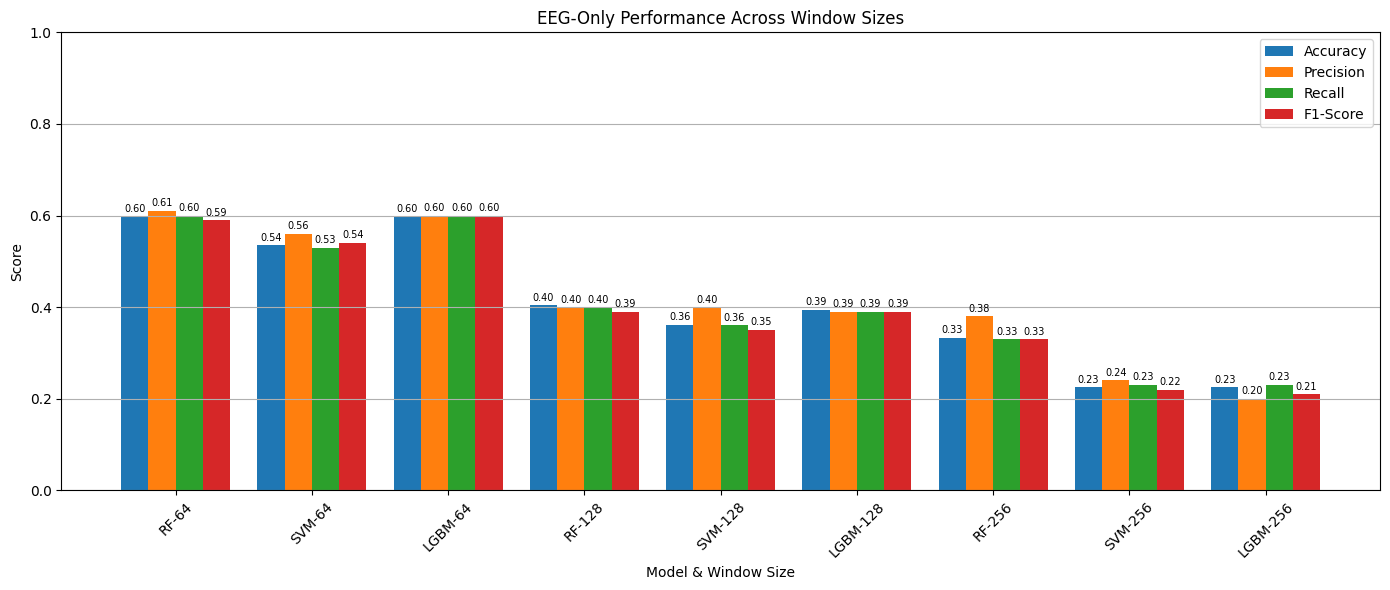

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = [
    'RF-64', 'SVM-64', 'LGBM-64',
    'RF-128', 'SVM-128', 'LGBM-128',
    'RF-256', 'SVM-256', 'LGBM-256'
]

accuracy = [0.597, 0.535, 0.597, 0.404, 0.361, 0.394, 0.333, 0.225, 0.225]
precision = [0.61, 0.56, 0.60, 0.40, 0.40, 0.39, 0.38, 0.24, 0.20]
recall = [0.60, 0.53, 0.60, 0.40, 0.36, 0.39, 0.33, 0.23, 0.23]
f1 = [0.59, 0.54, 0.60, 0.39, 0.35, 0.39, 0.33, 0.22, 0.21]

x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(14, 6))

bars1 = plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
bars2 = plt.bar(x - 0.5*width, precision, width, label='Precision')
bars3 = plt.bar(x + 0.5*width, recall, width, label='Recall')
bars4 = plt.bar(x + 1.5*width, f1, width, label='F1-Score')

# Add values
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', fontsize=7)

plt.xlabel("Model & Window Size")
plt.ylabel("Score")
plt.title("EEG-Only Performance Across Window Sizes")
plt.xticks(x, labels, rotation=45)
plt.ylim(0, 1)

plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The analysis across different window sizes reveals that smaller windows (64) consistently achieve better performance compared to larger window sizes. As the window size increases to 128 and 256, there is a significant decline in accuracy and other evaluation metrics across all models, with SVM showing the most pronounced degradation. This trend indicates that smaller window sizes are more effective in capturing short-term temporal variations in EEG signals, whereas larger windows may smooth out critical patterns and introduce noise. Overall, the findings reinforce the importance of optimal window selection in improving EEG-based classification performance.

# **RQ3 - deep learning models(CNN, LSTM) EEG n EEG+motion sensors data**

# Here we will train DL models - here we can use raw data - without flattening

# basically we will train DL models on both - EEG only data and EEG + motion sensors data

In [ ]:
# ============================================
# 1. IMPORTS
# ============================================
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical   # ✅ IMPORTANT

# ============================================
# 2. DATA PATH
# ============================================
data_path = "/content/drive/MyDrive/sajid_EEG_project/updated_csv_data_EEG"

# ============================================
# 3. FILE → LABEL MAP
# ============================================
file_label_map = {
    "Sub1EB.csv": "eye_blink",
    "Sub1EBM.csv": "eyebrow",
    "Sub1EM.csv": "eye_movement",
    "Sub1HS.csv": "head_shake",
    "Sub1HT.csv": "head_nod",
    "Sub1LS.csv": "leg_shake",
    "Sub1Music.csv": "music",
    "Sub1Relax.csv": "relax_closed",
    "Sub1Relaxopen.csv": "relax_open",
    "Sub1SUSD.csv": "sit_stand",
    "Sub1Talking.csv": "talking",
    "Sub1Walking.csv": "walking"
}

# ============================================
# 4. WINDOW FUNCTION
# ============================================
def create_windows(data, window_size=128, step=64):
    windows = []
    for i in range(0, len(data) - window_size, step):
        windows.append(data[i:i+window_size])
    return np.array(windows)


In [ ]:

# ============================================
# 5. BUILD DATASET
# ============================================
def build_dataset(use_eeg_only=False):

    X_all = []
    y_all = []

    for file, label in file_label_map.items():
        df = pd.read_csv(os.path.join(data_path, file))
        df.columns = [c.strip() for c in df.columns]
        df.fillna(method='ffill', inplace=True)

        # Remove motion
        if use_eeg_only:
            motion_keywords = [
                "MOT.GyroX","MOT.GyroY","MOT.GyroZ",
                "MOT.AccX","MOT.AccY","MOT.AccZ",
                "MOT.MagX","MOT.MagY","MOT.MagZ","EEG.RawCq"
            ]
            df = df[[col for col in df.columns if not any(k in col for k in motion_keywords)]]

        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(df)

        windows = create_windows(data_scaled)

        labels = [label] * len(windows)

        X_all.append(windows)
        y_all.extend(labels)

    X_all = np.vstack(X_all)
    y_all = np.array(y_all)

    return X_all, y_all

# ============================================
# 6. PREPARE DATA
# ============================================
def prepare_data(use_eeg_only=False):

    X, y = build_dataset(use_eeg_only)

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    num_classes = len(np.unique(y_encoded))
    y_cat = to_categorical(y_encoded, num_classes=num_classes)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_cat,
        test_size=0.2,
        stratify=y_encoded,
        random_state=42
    )

    return X_train, X_test, y_train, y_test, le, num_classes



In [ ]:
# ============================================
# 7. MODELS
# ============================================
def build_cnn(input_shape, num_classes):
    model = Sequential([
        Conv1D(64, 5, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Conv1D(128, 5, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_lstm(input_shape, num_classes):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),

        LSTM(64),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dropout(0.4),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ============================================
# 8. TRAIN + EVALUATE
# ============================================
def run_experiment(use_eeg_only=False, name=""):

    X_train, X_test, y_train, y_test, le, num_classes = prepare_data(use_eeg_only)

    input_shape = (X_train.shape[1], X_train.shape[2])

    early = EarlyStopping(patience=3, restore_best_weights=True)

    # CNN
    cnn = build_cnn(input_shape, num_classes)
    cnn.fit(X_train, y_train,
            epochs=20,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early],
            verbose=1)

    # LSTM
    lstm = build_lstm(input_shape, num_classes)
    lstm.fit(X_train, y_train,
             epochs=20,
             batch_size=32,
             validation_split=0.2,
             callbacks=[early],
             verbose=1)

    for model, mname in [(cnn, "CNN"), (lstm, "LSTM")]:
        y_pred = np.argmax(model.predict(X_test), axis=1)
        y_true = np.argmax(y_test, axis=1)

        print(f"\n==== {mname} ({name}) ====")
        print("Accuracy:", accuracy_score(y_true, y_pred))
        print(classification_report(y_true, y_pred))

        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d',
                    xticklabels=le.classes_,
                    yticklabels=le.classes_)
        plt.title(f"{mname} - {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()


/tmp/ipykernel_2679/202247964.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/202247964.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/202247964.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/202247964.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/202247964.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.1116 - loss: 2.5886 - val_accuracy: 0.2530 - val_loss: 2.4085
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.2760 - loss: 2.2397 - val_accuracy: 0.2711 - val_loss: 2.2275
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3514 - loss: 1.9404 - val_accuracy: 0.4096 - val_loss: 1.9213
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4781 - loss: 1.5582 - val_accuracy: 0.4940 - val_loss: 1.6841
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5973 - loss: 1.1760 - val_accuracy: 0.5723 - val_loss: 1.4506
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6893 - loss: 0.9252 - val_accuracy: 0.6325 - val_loss: 1.3867
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7994 - loss: 0.6414 - val_accuracy: 0.7651 - val_loss: 1.0501
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8703 - loss: 0.4639 - val_accuracy: 0.7349 - val_loss: 1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 276ms/step - accuracy: 0.1056 - loss: 2.4899 - val_accuracy: 0.1446 - val_loss: 2.4524
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 323ms/step - accuracy: 0.1508 - loss: 2.4150 - val_accuracy: 0.1867 - val_loss: 2.4179
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.2036 - loss: 2.3385 - val_accuracy: 0.1807 - val_loss: 2.3700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

==== CNN (EEG + Motion) ====
Accuracy: 0.7788461538461539
              precision    recall  f1-score   support

           0       0.94      0.89      0.91        18
           1       0.68      0.68      0.68        19
           2       0.71      0.94      0.81        18
           3       0.89      0.94      0.91        17
           4       0.84      0.89      0.86        18
           5       0.48      0.69      0.56        16
           6       0.94      0.89      0.91        18
           7       0.80      0.71      0.75        17
           8       0.79      0.65      0.7

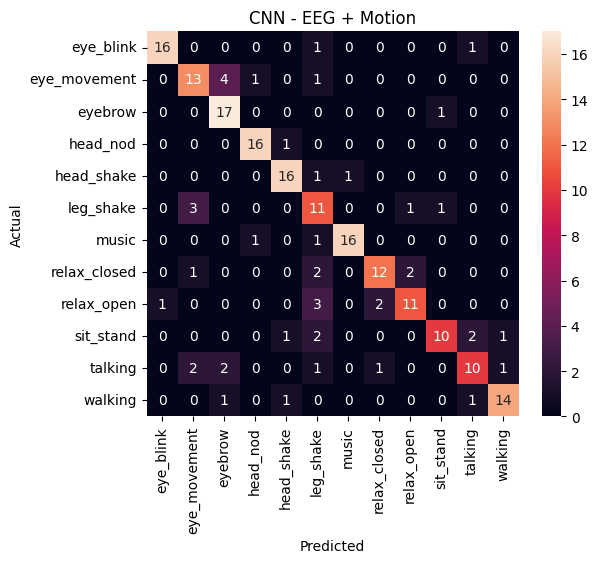

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step

==== LSTM (EEG + Motion) ====
Accuracy: 0.16346153846153846
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.00      0.00      0.00        19
           2       0.23      0.39      0.29        18
           3       0.11      0.12      0.11        17
           4       0.21      0.33      0.26        18
           5       0.21      0.19      0.20        16
           6       0.20      0.28      0.23        18
           7       0.14      0.06      0.08        17
           8       0.17      0.12      0.14        17
           9       0.44      0.25      0.32        16
          10       0.11      0.18      0.14        17
          11       0.20      0.06      0.09        17

    accuracy                           0.16       208
   macro avg       0.17      0.16      0.16       208
weighted avg       0.17      0.16      0.15       208



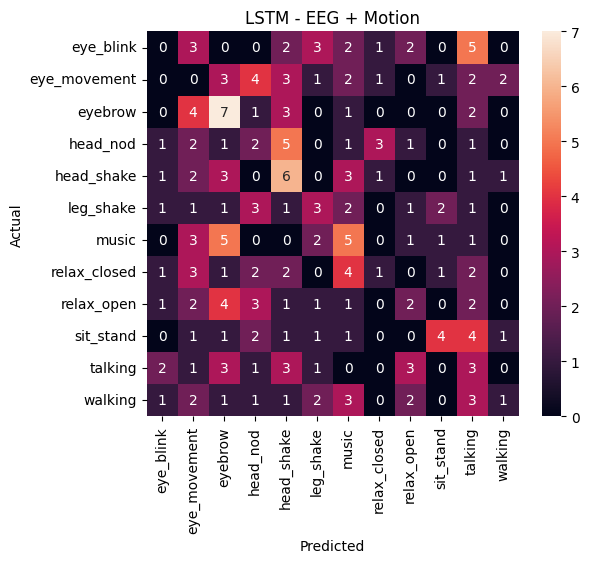

/tmp/ipykernel_2679/202247964.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/202247964.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/202247964.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/202247964.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/202247964.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.1161 - loss: 2.5536 - val_accuracy: 0.1928 - val_loss: 2.3425
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.2383 - loss: 2.2709 - val_accuracy: 0.3012 - val_loss: 2.1105
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3228 - loss: 2.0333 - val_accuracy: 0.3494 - val_loss: 1.9440
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4148 - loss: 1.7792 - val_accuracy: 0.3373 - val_loss: 1.8571
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4706 - loss: 1.5623 - val_accuracy: 0.4518 - val_loss: 1.6187
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5581 - loss: 1.3665 - val_accuracy: 0.5000 - val_loss: 1.5481
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5958 - loss: 1.1986 - val_accuracy: 0.4880 - val_loss: 1.4370
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6652 - loss: 0.9859 - val_accuracy: 0.5542 - v

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 268ms/step - accuracy: 0.1056 - loss: 2.4865 - val_accuracy: 0.1747 - val_loss: 2.4344
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 266ms/step - accuracy: 0.1644 - loss: 2.4176 - val_accuracy: 0.1627 - val_loss: 2.3867
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 311ms/step - accuracy: 0.1810 - loss: 2.3544 - val_accuracy: 0.2108 - val_loss: 2.3129
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

==== CNN (EEG Only) ====
Accuracy: 0.5288461538461539
              precision    recall  f1-score   support

           0       0.71      0.67      0.69        18
           1       0.29      0.32      0.30        19
           2       0.27      0.22      0.24        18
           3       0.47      0.47      0.47        17
           4       0.65      0.61      0.63        18
           5       0.73      0.50      0.59        16
           6       0.77      0.94      0.85        18
           7       0.71      0.59      0.65        17
           8       0.63      0.71      0.67   

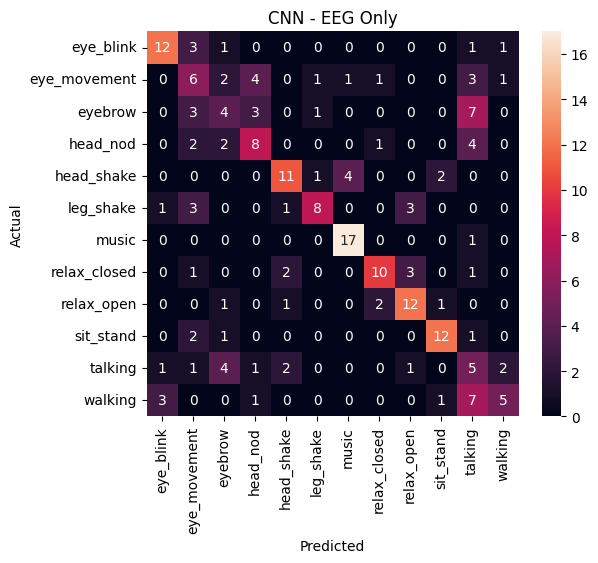

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step

==== LSTM (EEG Only) ====
Accuracy: 0.1875
              precision    recall  f1-score   support

           0       0.10      0.11      0.11        18
           1       0.00      0.00      0.00        19
           2       0.50      0.06      0.10        18
           3       0.18      0.18      0.18        17
           4       0.00      0.00      0.00        18
           5       0.00      0.00      0.00        16
           6       0.35      0.94      0.52        18
           7       0.20      0.24      0.22        17
           8       0.14      0.59      0.22        17
           9       0.12      0.06      0.08        16
          10       0.00      0.00      0.00        17
          11       0.07      0.06      0.06        17

    accuracy                           0.19       208
   macro avg       0.14      0.19      0.12       208
weighted avg       0.14      0.19      0.12       208



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


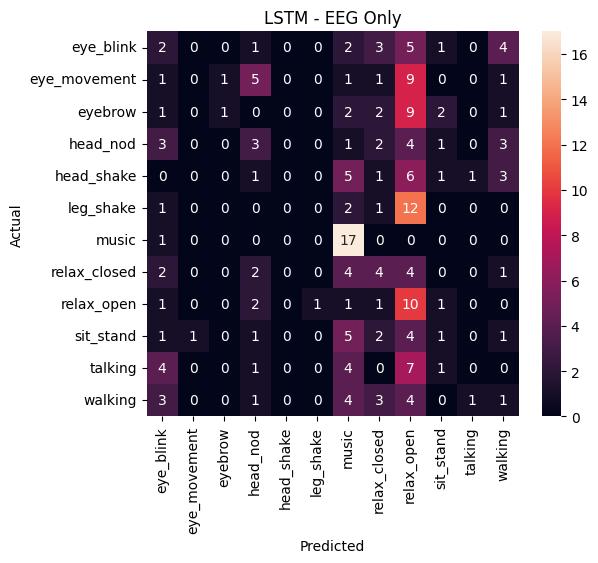

In [ ]:

# ============================================
# 9. RUN
# ============================================
run_experiment(use_eeg_only=False, name="EEG + Motion")
run_experiment(use_eeg_only=True, name="EEG Only")

Data Type	Model	Accuracy	Precision (Weighted Avg)	Recall (Weighted Avg)	F1-Score (Weighted Avg)

EEG + Motion	- CNN	0.78	0.79	0.78	0.78

EEG + Motion	- LSTM	0.16	0.17	0.16	0.15

EEG Only	- CNN	0.53	0.55	0.53	0.53

EEG Only	- LSTM	0.19	0.14	0.19	0.12

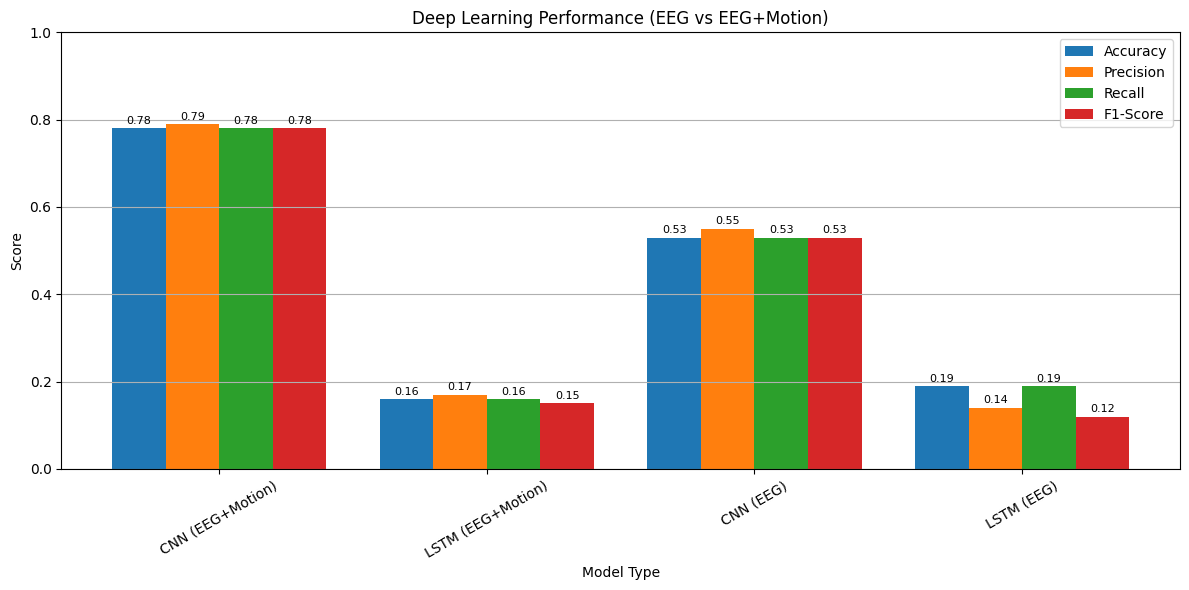

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['CNN (EEG+Motion)', 'LSTM (EEG+Motion)', 'CNN (EEG)', 'LSTM (EEG)']

accuracy = [0.78, 0.16, 0.53, 0.19]
precision = [0.79, 0.17, 0.55, 0.14]
recall = [0.78, 0.16, 0.53, 0.19]
f1 = [0.78, 0.15, 0.53, 0.12]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12,6))

bars1 = plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
bars2 = plt.bar(x - 0.5*width, precision, width, label='Precision')
bars3 = plt.bar(x + 0.5*width, recall, width, label='Recall')
bars4 = plt.bar(x + 1.5*width, f1, width, label='F1-Score')

# Value labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', fontsize=8)

plt.xticks(x, models, rotation=30)
plt.ylim(0,1)
plt.xlabel("Model Type")
plt.ylabel("Score")
plt.title("Deep Learning Performance (EEG vs EEG+Motion)")
plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()

The results clearly demonstrate that CNN significantly outperforms LSTM across both EEG-only and multimodal (EEG + Motion) data. The CNN model achieves the highest performance when using combined EEG and motion sensor inputs, highlighting the effectiveness of multimodal data fusion. In contrast, LSTM exhibits extremely low performance in both cases, suggesting its limitations in learning meaningful temporal dependencies from the given dataset. Overall, CNN proves to be more robust and suitable for this classification task, particularly when enriched with additional sensor data.

# **Experiments run on diff Window sizes DL for EEG + motion sensor data & comparison table**

In [ ]:
# ============================================
# IMPORTS
# ============================================
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Dropout
from tensorflow.keras.utils import to_categorical

# ============================================
# FILE PATH
# ============================================
data_path = "/content/drive/MyDrive/sajid_EEG_project/updated_csv_data_EEG"  # CHANGE THIS

# ============================================
# FILE → LABEL MAP
# ============================================
file_label_map = {
    "Sub1SUSD.csv": "sit_stand",
    "Sub1Talking.csv": "talking",
    "Sub1Walking.csv": "walking",
    "Sub1EB.csv": "eye_blink",
    "Sub1EBM.csv": "eyebrow",
    "Sub1EM.csv": "eye_movement",
    "Sub1HS.csv": "head_shake",
    "Sub1HT.csv": "head_nod",
    "Sub1LS.csv": "leg_shake",
    "Sub1Music.csv": "music",
    "Sub1Relax.csv": "relaxed_closed",
    "Sub1Relaxopen.csv": "relaxed_open"
}

# ============================================
# WINDOW FUNCTION
# ============================================
def create_windows(data, window_size=128, overlap=0.5):
    step = int(window_size * (1 - overlap))  #

    windows = []
    for i in range(0, len(data) - window_size, step):
        windows.append(data[i:i+window_size])

    return np.array(windows)



In [ ]:
# ============================================
# BUILD DATASET (EEG + MOTION)
# ============================================
def build_dataset(window_size=128, overlap=0.5):

    X_all = []
    y_all = []


    common_cols = None
    for file in file_label_map:
        df = pd.read_csv(os.path.join(data_path, file))
        cols = set(df.columns)

        if common_cols is None:
            common_cols = cols
        else:
            common_cols = common_cols.intersection(cols)

    common_cols = sorted(list(common_cols))

    # Build dataset
    for file, label in file_label_map.items():
        df = pd.read_csv(os.path.join(data_path, file))
        df = df[common_cols]

        df.fillna(method='ffill', inplace=True)

        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(df)

        # ✅ windowing
        windows = create_windows(data_scaled, window_size, overlap)

        labels = [label] * len(windows)

        X_all.append(windows)
        y_all.extend(labels)

    X_all = np.vstack(X_all)
    y_all = np.array(y_all)

    return X_all, y_all

# ============================================
# CNN MODEL
# ============================================
def build_cnn(input_shape, num_classes):
    model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# ============================================
# LSTM MODEL
# ============================================
def build_lstm(input_shape, num_classes):
    model = Sequential([
        LSTM(128, input_shape=input_shape),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:


# ============================================
# MAIN EXPERIMENT LOOP as 128 is already done
# ============================================
window_sizes = [64, 128, 256]
overlap = 0.5

le = LabelEncoder()

for w in window_sizes:
    print(f"\n\n========= WINDOW SIZE: {w} =========")

    # Load dataset
    X, y = build_dataset(window_size=w, overlap=overlap)

    # Encode labels
    y_encoded = le.fit_transform(y)
    y_cat = to_categorical(y_encoded)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_cat, test_size=0.2, stratify=y_encoded, random_state=42
    )

    #  dtype (important for DL)
    X_train = X_train.astype(np.float32)
    X_test = X_test.astype(np.float32)

    input_shape = (X_train.shape[1], X_train.shape[2])
    num_classes = y_cat.shape[1]

    # =====================================
    # CNN
    # =====================================
    cnn = build_cnn(input_shape, num_classes)

    cnn.fit(X_train, y_train,
            epochs=15,
            batch_size=32,
            validation_split=0.2,
            verbose=0)

    y_pred_cnn = np.argmax(cnn.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)

    print("\n==== CNN Results ====")
    print("Accuracy:", accuracy_score(y_true, y_pred_cnn))

    # =====================================
    # LSTM
    # =====================================
    lstm = build_lstm(input_shape, num_classes)

    lstm.fit(X_train, y_train,
             epochs=15,
             batch_size=32,
             validation_split=0.2,
             verbose=0)

    y_pred_lstm = np.argmax(lstm.predict(X_test), axis=1)

    print("\n==== LSTM Results ====")
    print("Accuracy:", accuracy_score(y_true, y_pred_lstm))



========= WINDOW SIZE: 64 =========


/tmp/ipykernel_2679/2802288078.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2802288078.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2802288078.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2802288078.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2802288078.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Us

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

==== CNN Results ====
Accuracy: 0.8926014319809069


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step

==== LSTM Results ====
Accuracy: 0.7684964200477327


========= WINDOW SIZE: 128 =========


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step

==== LSTM Results ====
Accuracy: 0.4855769230769231


========= WINDOW SIZE: 256 =========


/tmp/ipykernel_2679/2802288078.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2802288078.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2802288078.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2802288078.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_2679/2802288078.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Us

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

==== CNN Results ====
Accuracy: 0.6862745098039216


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step

==== LSTM Results ====
Accuracy: 0.21568627450980393


*📊 Deep Learning Results (EEG + Motion Sensors)

Window Size	CNN Accuracy	LSTM Accuracy

64	0.8926	0.7685

128	0.8173	0.4856

256	0.6863	0.2157*




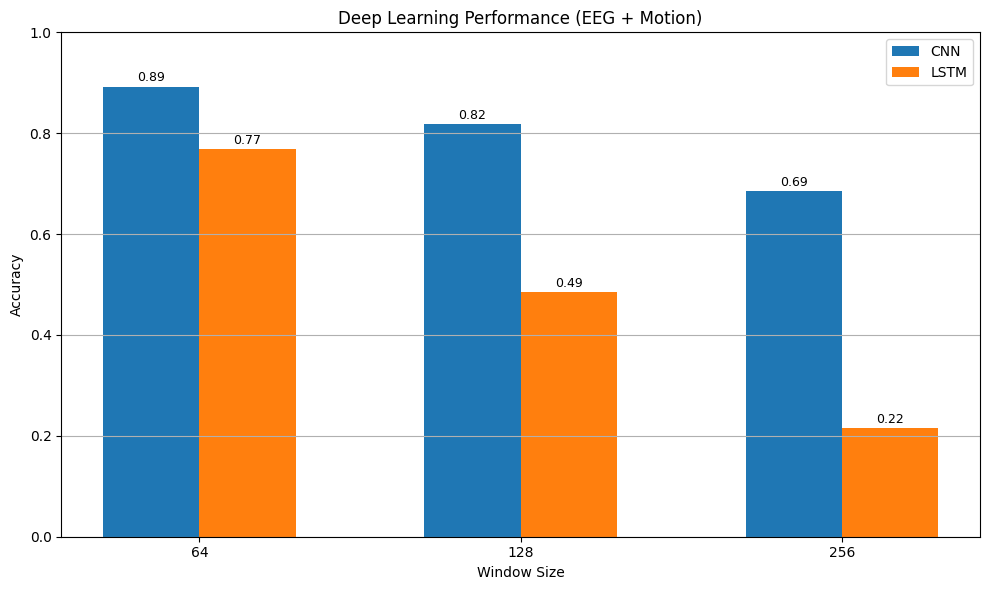

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

windows = ['64', '128', '256']

cnn = [0.8926, 0.8173, 0.6863]
lstm = [0.7685, 0.4856, 0.2157]

x = np.arange(len(windows))
width = 0.3

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, cnn, width, label='CNN')
bars2 = plt.bar(x + width/2, lstm, width, label='LSTM')

# Labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', fontsize=9)

plt.xticks(x, windows)
plt.xlabel("Window Size")
plt.ylabel("Accuracy")
plt.title("Deep Learning Performance (EEG + Motion)")
plt.ylim(0,1)

plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()

The results indicate that smaller window sizes (64) yield the highest accuracy for both CNN and LSTM models when using EEG combined with motion sensor data. As the window size increases, performance declines steadily, with LSTM showing a sharp drop at larger window sizes. CNN maintains relatively strong performance across all windows but still experiences degradation. These findings suggest that shorter temporal windows are more effective in capturing meaningful patterns, while larger windows may dilute critical signal variations, particularly affecting sequence-based models like LSTM.

# **Experiments run on diff Window sizes DL for only EEG data without motion sensor data & comparison table**

In [ ]:
# ============================================
# IMPORTS
# ============================================
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Dropout
from tensorflow.keras.utils import to_categorical

# ============================================
# FILE PATH
# ============================================
data_path = "/content/drive/MyDrive/sajid_EEG_project/updated_csv_data_EEG"  # CHANGE THIS

# ============================================
# FILE → LABEL MAP
# ============================================
file_label_map = {
    "Sub1SUSD.csv": "sit_stand",
    "Sub1Talking.csv": "talking",
    "Sub1Walking.csv": "walking",
    "Sub1EB.csv": "eye_blink",
    "Sub1EBM.csv": "eyebrow",
    "Sub1EM.csv": "eye_movement",
    "Sub1HS.csv": "head_shake",
    "Sub1HT.csv": "head_nod",
    "Sub1LS.csv": "leg_shake",
    "Sub1Music.csv": "music",
    "Sub1Relax.csv": "relaxed_closed",
    "Sub1Relaxopen.csv": "relaxed_open"
}

# ============================================
# WINDOW FUNCTION
# ============================================
def create_windows(data, window_size=128, overlap=0.5):
    step = int(window_size * (1 - overlap))
    windows = []
    for i in range(0, len(data) - window_size, step):
        windows.append(data[i:i+window_size])
    return np.array(windows)

# ============================================
# BUILD DATASET (EEG ONLY)
# ============================================
def build_dataset_eeg_only(window_size=128, overlap=0.5):

    X_all = []
    y_all = []

    common_cols = None

    # EEG-only columns
    for file in file_label_map:
        df = pd.read_csv(os.path.join(data_path, file))

        # Remove motion sensor columns
        motion_keywords = [
              "MOT.GyroX", "MOT.GyroY", "MOT.GyroZ",
              "MOT.AccX",  "MOT.AccY",  "MOT.AccZ",
              "MOT.MagX",  "MOT.MagY",  "MOT.MagZ"
            ]
        df = df[[col for col in df.columns if not any(k in col for k in motion_keywords)]]

        cols = set(df.columns)

        if common_cols is None:
            common_cols = cols
        else:
            common_cols = common_cols.intersection(cols)

    common_cols = sorted(list(common_cols))

    # Build dataset
    for file, label in file_label_map.items():
        df = pd.read_csv(os.path.join(data_path, file))

        # Remove motion sensor columns
        motion_keywords = [
              "MOT.GyroX", "MOT.GyroY", "MOT.GyroZ",
              "MOT.AccX",  "MOT.AccY",  "MOT.AccZ",
              "MOT.MagX",  "MOT.MagY",  "MOT.MagZ"
            ]
        df = df[[col for col in df.columns if not any(k in col for k in motion_keywords)]]

        df = df[common_cols]

        #
        df.ffill(inplace=True)

        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(df)

        windows = create_windows(data_scaled, window_size, overlap)

        labels = [label] * len(windows)

        X_all.append(windows)
        y_all.extend(labels)

    X_all = np.vstack(X_all)
    y_all = np.array(y_all)

    return X_all, y_all


In [ ]:

# ============================================
# CNN MODEL
# ============================================
def build_cnn(input_shape, num_classes):
    model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# ============================================
# LSTM MODEL
# ============================================
def build_lstm(input_shape, num_classes):
    model = Sequential([
        LSTM(128, input_shape=input_shape),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:


# ============================================
# MAIN EXPERIMENT LOOP
# ============================================
window_sizes = [64, 128, 256]
overlap = 0.5

le = LabelEncoder()

for w in window_sizes:
    print(f"\n\n========= WINDOW SIZE: {w} =========")

    X, y = build_dataset_eeg_only(window_size=w, overlap=overlap)

    y_encoded = le.fit_transform(y)
    y_cat = to_categorical(y_encoded)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_cat, test_size=0.2, stratify=y_encoded, random_state=42
    )

    #  dtype
    X_train = X_train.astype(np.float32)
    X_test = X_test.astype(np.float32)

    input_shape = (X_train.shape[1], X_train.shape[2])
    num_classes = y_cat.shape[1]

    # =====================================
    # CNN
    # =====================================
    cnn = build_cnn(input_shape, num_classes)

    cnn.fit(X_train, y_train,
            epochs=15,
            batch_size=32,
            validation_split=0.2,
            verbose=0)

    y_pred_cnn = np.argmax(cnn.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)

    print("\n==== CNN (EEG ONLY) ====")
    print("Accuracy:", accuracy_score(y_true, y_pred_cnn))

    # =====================================
    # LSTM
    # =====================================
    lstm = build_lstm(input_shape, num_classes)

    lstm.fit(X_train, y_train,
             epochs=15,
             batch_size=32,
             validation_split=0.2,
             verbose=0)

    y_pred_lstm = np.argmax(lstm.predict(X_test), axis=1)

    print("\n==== LSTM (EEG ONLY) ====")
    print("Accuracy:", accuracy_score(y_true, y_pred_lstm))



========= WINDOW SIZE: 64 =========


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

==== CNN (EEG ONLY) ====
Accuracy: 0.7040572792362768


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

==== LSTM (EEG ONLY) ====
Accuracy: 0.5298329355608592


========= WINDOW SIZE: 128 =========


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step

==== LSTM (EEG ONLY) ====
Accuracy: 0.36538461538461536


========= WINDOW SIZE: 256 =========


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

==== CNN (EEG ONLY) ====
Accuracy: 0.4803921568627451


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step

==== LSTM (EEG ONLY) ====
Accuracy: 0.22549019607843138


Deep Learning Results (EEG Only)

Window Size	CNN Accuracy	LSTM Accuracy

64           	0.7041	0.5298

128          	0.5625	0.3654

256          	0.4804	0.2255

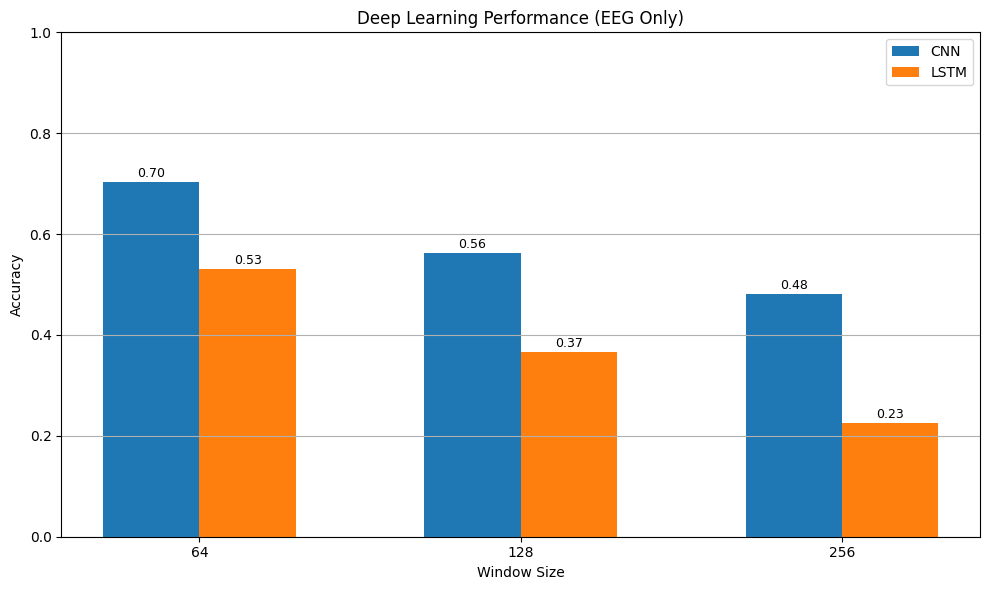

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

windows = ['64', '128', '256']

cnn = [0.7041, 0.5625, 0.4804]
lstm = [0.5298, 0.3654, 0.2255]

x = np.arange(len(windows))
width = 0.3

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, cnn, width, label='CNN')
bars2 = plt.bar(x + width/2, lstm, width, label='LSTM')

# Labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', fontsize=9)

plt.xticks(x, windows)
plt.xlabel("Window Size")
plt.ylabel("Accuracy")
plt.title("Deep Learning Performance (EEG Only)")
plt.ylim(0,1)

plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()

The EEG-only results follow a similar trend, where smaller window sizes (64) achieve the best performance for both CNN and LSTM models. However, overall accuracy is lower compared to the multimodal setup, indicating the limitations of relying solely on EEG data. CNN continues to outperform LSTM across all window sizes, demonstrating its superior ability to capture spatial patterns in EEG signals. The performance degradation at larger window sizes further reinforces the importance of selecting an optimal window size for effective EEG-based classification.